dependencies

In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

Used splitfolders tool to split dataset into training, validation and test directories.

$ pip install split-folders

$ splitfolders --ratio 0.7 0.1 0.2 --output ./end-to-end-breast-cancer-classification-using-cnn/splited_dataset ./end-to-end-breast-cancer-classification-using-cnn/dataset

generate data

In [21]:
IMAGE_SIZE = 256
CHANNELS = 3
BATCH_SIZE=32

In [3]:

os.makedirs("../AugmentedImages/train", exist_ok=True)
os.makedirs("../AugmentedImages/val", exist_ok=True)
os.makedirs("../AugmentedImages/test", exist_ok=True)

visualize the original data splited

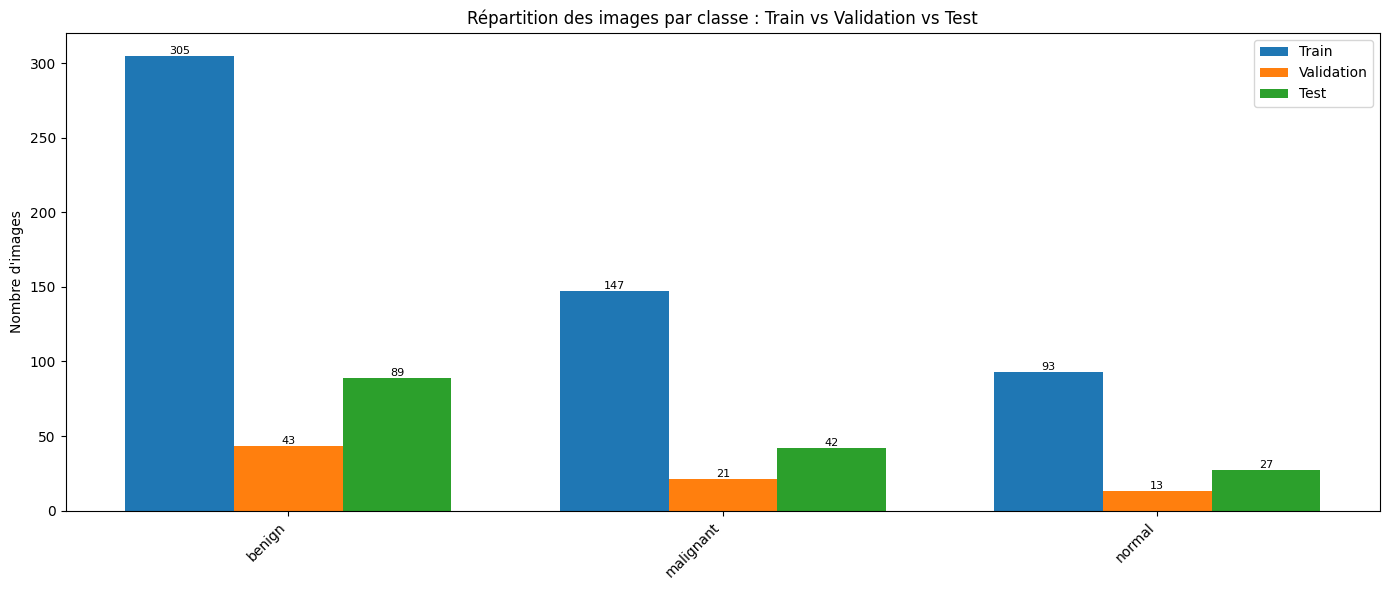

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

base_dir = "../splited_dataset"  # dossier contenant train, val, test
splits = ["train", "val", "test"]

# récupérer les classes à partir de train
classes = sorted([
    d for d in os.listdir(os.path.join(base_dir, "train"))
    if os.path.isdir(os.path.join(base_dir, "train", d))
])

# fonction de comptage
def count_images(folder):
    return len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".png", ".jpeg"))
    ])

# compter pour chaque split
data_counts = {split: [] for split in splits}

for split in splits:
    for cls in classes:
        class_folder = os.path.join(base_dir, split, cls)
        count = count_images(class_folder) if os.path.exists(class_folder) else 0
        data_counts[split].append(count)

# afficher graphique
x = np.arange(len(classes))  # positions des barres
width = 0.25  # largeur des barres

plt.figure(figsize=(14, 6))
bars_train = plt.bar(x - width, data_counts["train"], width, label="Train")
bars_val = plt.bar(x, data_counts["val"], width, label="Validation")
bars_test = plt.bar(x + width, data_counts["test"], width, label="Test")

# ---- Ajouter les chiffres au-dessus des barres ----
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            str(height),
            ha='center',
            va='bottom',
            fontsize=8
        )

add_labels(bars_train)
add_labels(bars_val)
add_labels(bars_test)

plt.xticks(x, classes, rotation=45, ha="right")
plt.ylabel("Nombre d'images")
plt.title("Répartition des images par classe : Train vs Validation vs Test")
plt.legend()
plt.tight_layout()
plt.show()


generate data

In [5]:
train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        horizontal_flip=True
)
train_generator = train_datagen.flow_from_directory(
    '../splited_dataset/train',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32,
    class_mode="sparse",
    #save_to_dir="../AugmentedImages/train",
    #save_prefix="aug",
    #save_format="jpg"
)


Found 545 images belonging to 3 classes.


In [6]:
# Générer et sauvegarder 32 images augmentées
i = 0
for images, labels in train_generator:
    i += 1
    if i >= 32:  # stop après 32 lots
        break


In [7]:
train_generator.class_indices


{'benign': 0, 'malignant': 1, 'normal': 2}

In [8]:
class_names = list(train_generator.class_indices.keys())
class_names

['benign', 'malignant', 'normal']

In [9]:
validation_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        horizontal_flip=True)
validation_generator = validation_datagen.flow_from_directory(
        '../splited_dataset/val',
        target_size=(IMAGE_SIZE,IMAGE_SIZE),
        batch_size=32,
        class_mode="sparse",
        #"save_to_dir="../AugmentedImages/val",
        #save_prefix="aug",
        #save_format="jpg"
)

Found 77 images belonging to 3 classes.


In [10]:
# Générer et sauvegarder 3 images augmentées
i = 0
for images, labels in validation_generator:
    i += 1
    if i >= 3:  # stop après 3 lots
        break

In [11]:
test_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        horizontal_flip=True)
test_generator = test_datagen.flow_from_directory(
        '../splited_dataset/test',
        target_size=(IMAGE_SIZE,IMAGE_SIZE),
        batch_size=32,
        class_mode="sparse",
        #save_to_dir="../AugmentedImages/test",
        #save_prefix="aug",
        #save_format="jpg"
)

Found 158 images belonging to 3 classes.


In [12]:
# Générer et sauvegarder 3 images augmentées
i = 0
for images, labels in test_generator:
    i += 1
    if i >= 4:  # stop après 3 lots
        break

visualize data

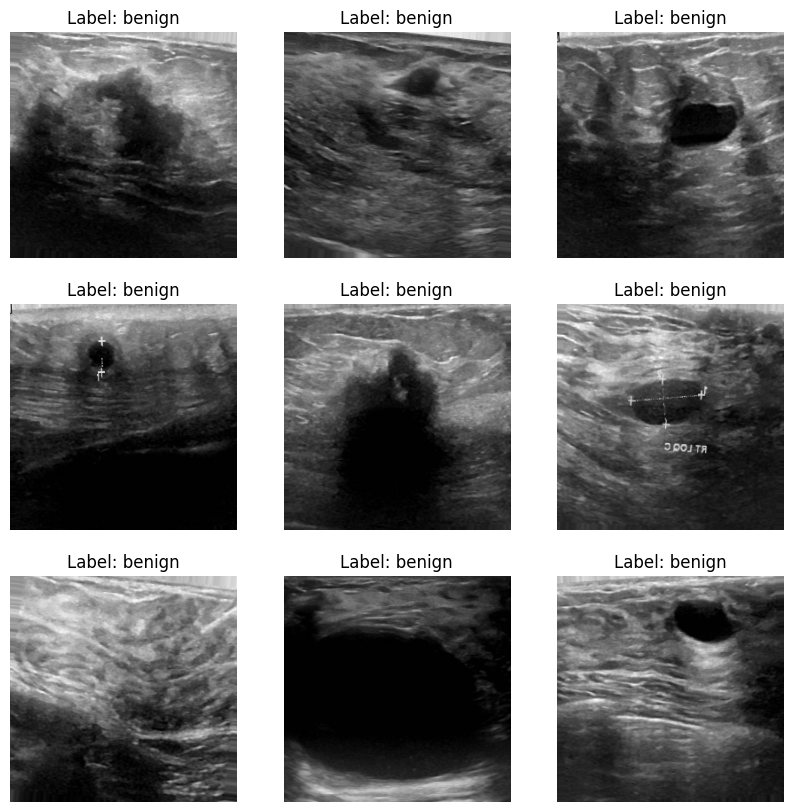

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of images and labels
images, labels = next(validation_generator)

# Plot the first 9 images in the batch
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {class_names[np.argmax(labels[i])]}")
    plt.axis("off")
plt.show()

In [15]:

print("Classes :", train_generator.class_indices)
print("Nb images train :", train_generator.samples)
print("Nb images val   :", validation_generator.samples)
print("Nb images test  :", test_generator.samples)

Classes : {'benign': 0, 'malignant': 1, 'normal': 2}
Nb images train : 545
Nb images val   : 77
Nb images test  : 158


concatinate dataset : original data + generated data

build the model 

In [16]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(32, kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

/Users/ikram/miniconda3/envs/tf-arm/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [17]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

recréer de nouveaux générateurs qui pointent vers ../merged_dataset, et les utiliser dans model.fit

In [25]:
steps_per_epoch    = train_generator.samples // BATCH_SIZE
validation_steps   = validation_generator.samples // BATCH_SIZE

history = model.fit(
    train_generator,
    epochs=100,
    steps_per_epoch=steps_per_epoch,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    verbose=1,
)


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 786ms/step - accuracy: 0.6530 - loss: 0.7632 - val_accuracy: 0.6406 - val_loss: 0.7605
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5625 - loss: 0.9667 - val_accuracy: 0.7188 - val_loss: 0.7022
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 717ms/step - accuracy: 0.6589 - loss: 0.7360 - val_accuracy: 0.6562 - val_loss: 0.7510
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.6250 - loss: 0.7448 - val_accuracy: 0.5938 - val_loss: 0.8874
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 705ms/step - accuracy: 0.6628 - loss: 0.7330 - val_accuracy: 0.7031 - val_loss: 0.7138
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.8438 - loss: 0.4816 - val_accuracy: 0.6562 - val_loss: 0.8922
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 719ms/step - accuracy: 0.6823 - loss: 0.7080 - val_accuracy: 0.6406 - val_loss: 0.9153
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.7188 - loss: 0.7712 - val_accu

In [26]:
scores = model.evaluate(test_generator)
print(scores)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 404ms/step - accuracy: 0.7911 - loss: 0.8486
[0.8485971093177795, 0.7911392450332642]


In [27]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 444ms/step - accuracy: 0.7785 - loss: 0.8082
Test loss: 0.8082074522972107
Test accuracy: 0.7784810066223145


In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

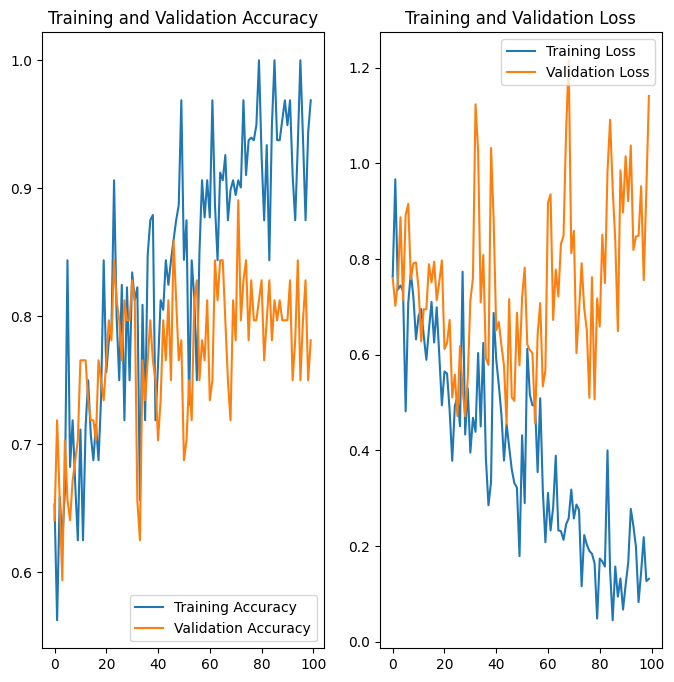

In [30]:
EPOCHS = 100

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Run prediction on a sample image



first image to predict
actual label: benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
predicted label: benign


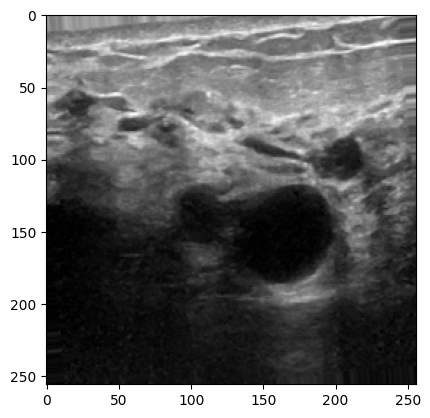

In [31]:
import numpy as np


for image_batch, label_batch in test_generator:
    first_image = image_batch[0]
    first_label = int(label_batch[0])
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(image_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])
    
    break

Write a function for inference

In [32]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i])
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


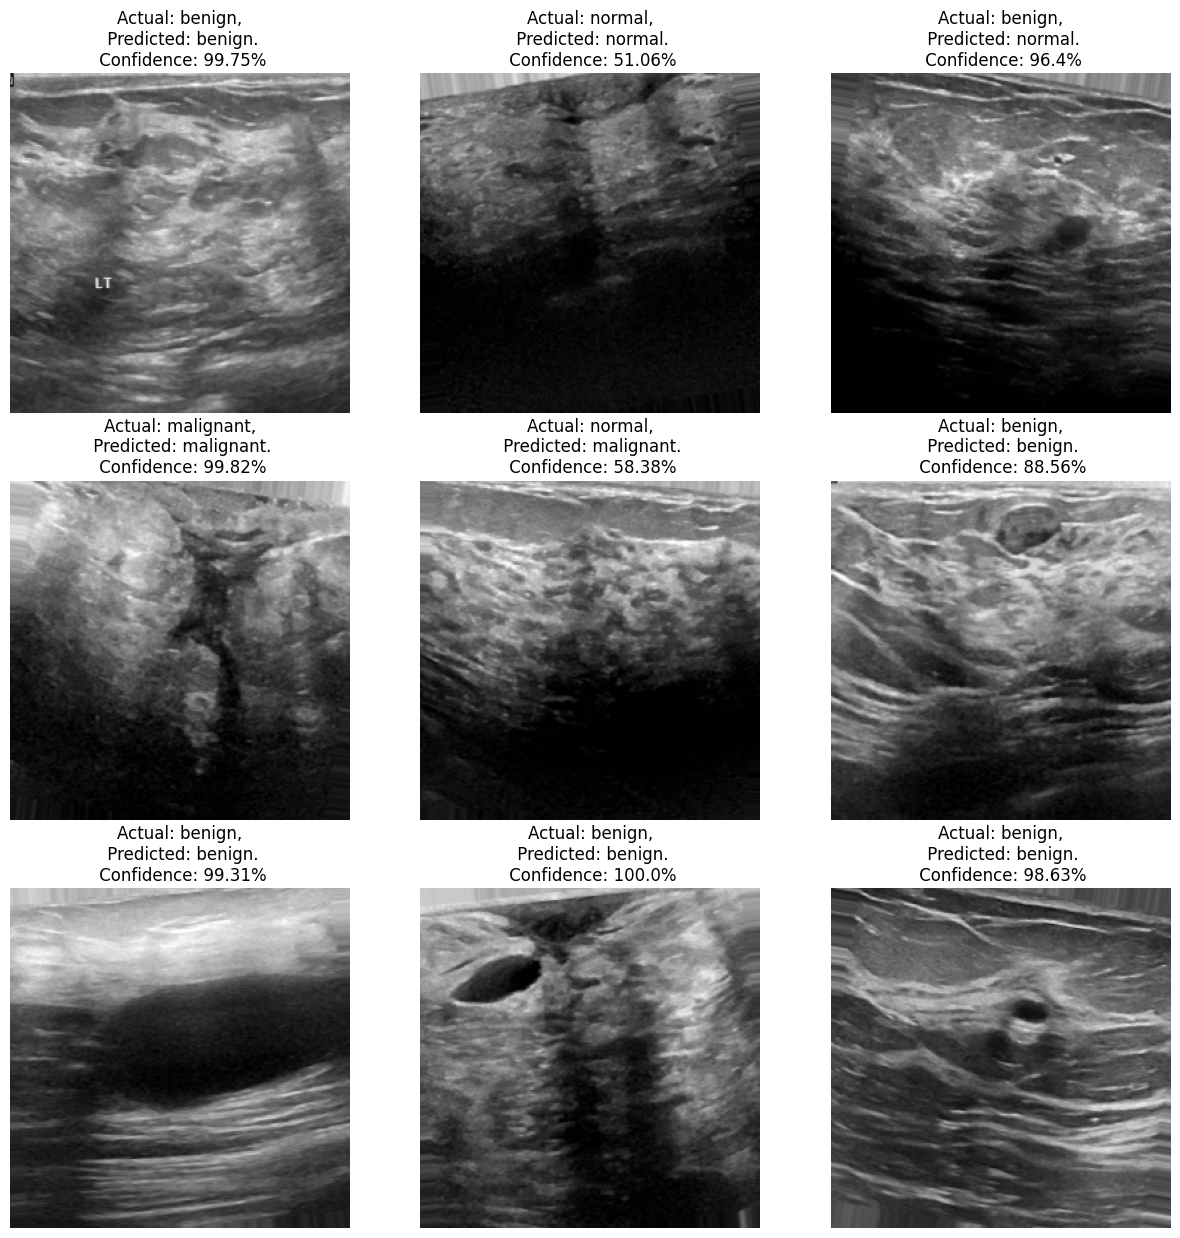

In [33]:
plt.figure(figsize=(15, 15))
for images, labels in test_generator:
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        
        predicted_class, confidence = predict(model, images[i])
        actual_class = class_names[int(labels[i])] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")
    break

In [34]:

import os

models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

# Récupérer uniquement les fichiers qui ont un nom numérique avant l'extension
existing_versions = []
for name in os.listdir(models_dir):
    if name.endswith(".h5"):
        base = name.replace(".h5", "")
        if base.isdigit():
            existing_versions.append(int(base))

model_version = max(existing_versions + [0]) + 1

save_path = os.path.join(models_dir, f"predict_breast_cancer_version{model_version}.h5")
model.save(save_path)

print(f"✅ Modèle sauvegardé dans : {os.path.abspath(save_path)}")

✅ Modèle sauvegardé dans : /Users/ikram/Desktop/github-project/end-to-end-breast-cancer-classification-using-cnn/models/predict_breast_cancer_version1.h5
